<a href="https://colab.research.google.com/github/sonixx00/Starshun/blob/main/LB10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Старшун софія ФІТ, 2-17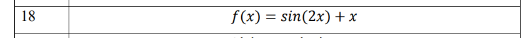

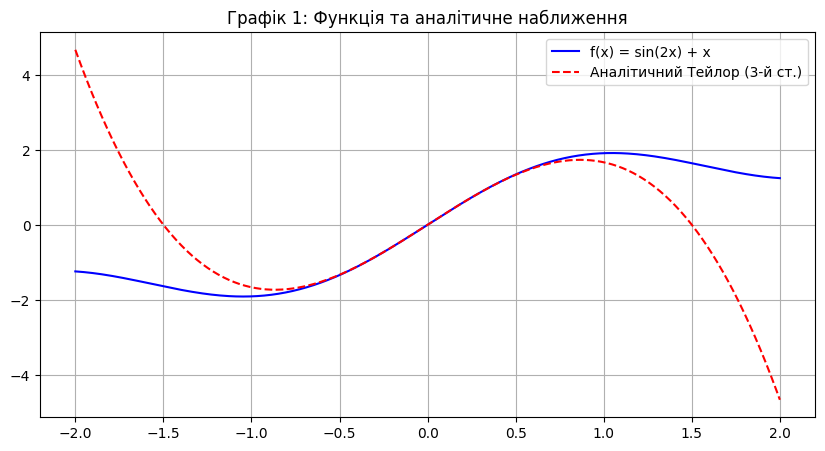

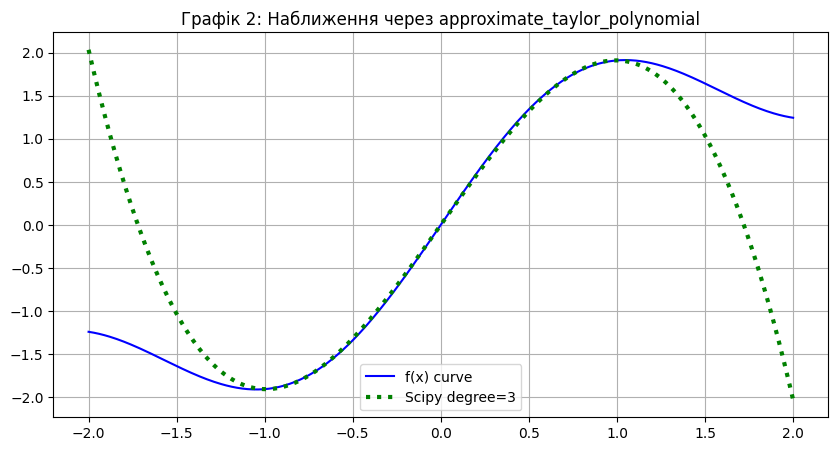

Ваш аналітичний поліном: -1.33333333333333*x**3 + 3.0*x
Поліном від Scipy:
         3             2
-0.9752 x + 8.882e-16 x + 2.885 x - 1.798e-16


In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import approximate_taylor_polynomial

# Задаємо символьну змінну та функцію для варіанта 18
x_sym = sp.symbols('x')
f_sym = sp.sin(2*x_sym) + x_sym

# 1. АНАЛІТИЧНИЙ ПІДХІД (Завдання 1)
x0 = 0
# Обчислюємо значення функції та похідних у точці 0
f_0 = f_sym.subs(x_sym, x0).evalf()
f1_0 = sp.diff(f_sym, x_sym).subs(x_sym, x0).evalf()
f2_0 = sp.diff(f_sym, x_sym, 2).subs(x_sym, x0).evalf()
f3_0 = sp.diff(f_sym, x_sym, 3).subs(x_sym, x0).evalf()

# Формуємо поліном за вашою правильною формулою: T3 = 3.0*x - 1.333*x**3
T3_analyt = f_0 + f1_0*x_sym + (f2_0/2)*x_sym**2 + (f3_0/6)*x_sym**3

# Графік 1: Аналітичне наближення
x_vals = np.linspace(-2, 2, 400)
f_vals = np.array([float(f_sym.subs(x_sym, val)) for val in x_vals])
t_analyt_vals = np.array([float(T3_analyt.subs(x_sym, val)) for val in x_vals])

plt.figure(figsize=(10, 5))
plt.plot(x_vals, f_vals, label="f(x) = sin(2x) + x", color='blue')
plt.plot(x_vals, t_analyt_vals, "--", label="Аналітичний Тейлор (3-й ст.)", color='red')
plt.title("Графік 1: Функція та аналітичне наближення")
plt.grid(True)
plt.legend()
plt.show()

# 2. ПІДХІД ЧЕРЕЗ SCIPY (Завдання 2)
def f_func(x):
    return np.sin(2*x) + x

degree = 3
# Використання scipy.interpolate.approximate_taylor_polynomial
taylor_scipy = approximate_taylor_polynomial(f_func, 0, degree, scale=1)

# Графік 2: Scipy наближення
plt.figure(figsize=(10, 5))
plt.plot(x_vals, f_vals, label="f(x) curve", color='blue')
plt.plot(x_vals, taylor_scipy(x_vals), ":", label=f"Scipy degree={degree}", color='green', lw=3)
plt.title("Графік 2: Наближення через approximate_taylor_polynomial")
plt.grid(True)
plt.legend()
plt.show()

print(f"Ваш аналітичний поліном: {T3_analyt}")
print(f"Поліном від Scipy:\n{taylor_scipy}")